## Start

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Works whether the notebook runs from the repo root or from analysis/
ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
CSV_PATH = ROOT / 'data' / 'raw' / 'ita_300a_2025.csv'
CSV_PATH, CSV_PATH.exists()

(WindowsPath('c:/Users/chico/Desktop/sdgku/OSHA-capstone/data/raw/ita_300a_2025.csv'),
 True)

## 1. Load


In [4]:
ID_COLUMNS = {
    'id': 'string',
    'establishment_id': 'string',
    'ein': 'string',
    'zip_code': 'string',
    'naics_code': 'string',
}

df = pd.read_csv(CSV_PATH, dtype=ID_COLUMNS, low_memory=False)
print(f'{len(df):,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:,.0f} MB')
df.head()

383,283 rows × 32 columns
Memory: 387 MB


,id,establishment_name,establishment_id,ein,company_name,street_address,city,state,zip_code,naics_code,naics_year,industry_description,establishment_type,size,annual_average_employees,total_hours_worked,no_injuries_illnesses,total_deaths,total_dafw_cases,total_djtr_cases,total_other_cases,total_dafw_days,total_djtr_days,total_injuries,total_skin_disorders,total_respiratory_conditions,total_poisonings,total_hearing_loss,total_other_illnesses,created_timestamp,change_reason,year_filing_for
0,2896135,Serenus Johnson Construction,49921,382818293,Serenus Johnson Construction,5178 Kasemeyer Road,Bay City,MI,48706,236220,"2,012.00",General Contractor - Commercial Contractor,1.00,21.00,48.00,"89,734.00",2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0,0.00,1/1/2026,NaN,"2,025.00"
1,2896136,Falls Insulation,157731,931009737,Falls Interior Systems Inc,3240 Fisher Rd NE,Salem,OR,97305,238310,"2,012.00",Building insulation contractors,1.00,2.00,23.00,"45,073.00",1.00,0.00,1.00,0.00,1.00,85.00,0.00,2.00,0,0.00,0.00,0,0.00,1/1/2026,NaN,"2,025.00"
2,2896131,Jenifer Street Market,910701,391328392,"Creative Grocery Concepts, Inc",2038 Jenifer Street,Madison,WI,53704,445110,"2,012.00","Commissaries, primarily groceries",1.00,21.00,40.00,"53,735.00",1.00,0.00,0.00,0.00,2.00,0.00,0.00,2.00,0,0.00,0.00,0,0.00,1/1/2026,NaN,"2,025.00"
3,2896130,"Crockett Enterprises, Inc.",919145,205134864,"Crockett Enterprises, Inc.",195 Van Hill Road,Greeneville,TN,37745,447110,"2,012.00",Convenience food with gasoline stations,1.00,2.00,114.00,"198,721.00",1.00,0.00,1.00,0.00,1.00,5.00,0.00,2.00,0,0.00,0.00,0,0.00,1/1/2026,NaN,"2,025.00"
4,2896137,Caberfae Peaks Ski and Golf Resort,1065720,453666214,Caberfae Management Corporation,1 Caberfae Lane,Cadillac,MI,49601,721110,"2,022.00",Ski lodges and resorts with accommodations,1.00,22.00,120.00,"123,321.00",1.00,0.00,2.00,0.00,1.00,15.00,0.00,3.00,0,0.00,0.00,0,0.00,1/1/2026,NaN,"2,025.00"


In [3]:
df.dtypes

id                               string
establishment_name                  str
establishment_id                 string
ein                              string
company_name                        str
street_address                      str
city                                str
state                               str
zip_code                         string
naics_code                       string
naics_year                      float64
industry_description                str
establishment_type              float64
size                            float64
annual_average_employees        float64
total_hours_worked              float64
no_injuries_illnesses           float64
total_deaths                    float64
total_dafw_cases                float64
total_djtr_cases                float64
total_other_cases               float64
total_dafw_days                 float64
total_djtr_days                 float64
total_injuries                  float64
total_skin_disorders                str


### 1.1 Malformed rows

total_skin_disorders and total_hearing_loss should be numeric.

In [6]:
malformed = df['id'].isna() | df['total_hours_worked'].isna()
print(f'Malformed rows: {malformed.sum():,}')
display(df[malformed].iloc[:, :12])

df = df[~malformed].copy()

# With the broken rows gone, every count column should parse as a number
COUNT_COLUMNS = df.columns[df.columns.get_loc('size'):df.columns.get_loc('total_other_illnesses') + 1]
df[COUNT_COLUMNS] = df[COUNT_COLUMNS].apply(pd.to_numeric, errors='raise').astype('Int64')
df['year_filing_for'] = pd.to_numeric(df['year_filing_for']).astype('Int64')
print(f'Rows remaining: {len(df):,}')
df.dtypes

Malformed rows: 0


,id,establishment_name,establishment_id,ein,company_name,street_address,city,state,zip_code,naics_code,naics_year,industry_description


Rows remaining: 383,277


id                               string
establishment_name                  str
establishment_id                 string
ein                              string
company_name                        str
street_address                      str
city                                str
state                               str
zip_code                         string
naics_code                       string
naics_year                      float64
industry_description                str
establishment_type              float64
size                              Int64
annual_average_employees          Int64
total_hours_worked                Int64
no_injuries_illnesses             Int64
total_deaths                      Int64
total_dafw_cases                  Int64
total_djtr_cases                  Int64
total_other_cases                 Int64
total_dafw_days                   Int64
total_djtr_days                   Int64
total_injuries                    Int64
total_skin_disorders              Int64


## 2. Nulls

In [5]:
nulls = pd.DataFrame({
    'nulls': df.isna().sum(),
    'pct': df.isna().mean() * 100,
}).query('nulls > 0').sort_values('nulls', ascending=False)
nulls

,nulls,pct
change_reason,369759,96.47
ein,43315,11.30
industry_description,26146,6.82
company_name,19053,4.97
establishment_type,437,0.11
street_address,1,0.00


## 3. Numeric overview

In [6]:
NUMERIC_COLUMNS = [
    'annual_average_employees', 'total_hours_worked',
    'total_deaths', 'total_dafw_cases', 'total_djtr_cases', 'total_other_cases',
    'total_dafw_days', 'total_djtr_days',
]
df[NUMERIC_COLUMNS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
annual_average_employees,"383,277.00",839.83,"241,512.76",0.00,0.00,2.00,16.00,39.00,102.00,389.00,"1,406.24","120,667,434.00"
total_hours_worked,"383,277.00","1,740,765.48","356,785,372.10",0.00,208.00,"2,202.00","23,407.00","66,103.00","172,118.00","699,306.20","2,841,922.28","140,142,000,000.00"
total_deaths,"383,277.00",0.00,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,16.00
total_dafw_cases,"383,277.00",1.23,6.81,0.00,0.00,0.00,0.00,0.00,1.00,5.00,15.00,"1,025.00"
total_djtr_cases,"383,277.00",1.04,12.00,0.00,0.00,0.00,0.00,0.00,1.00,4.00,14.00,"6,214.00"
total_other_cases,"383,277.00",1.34,13.84,0.00,0.00,0.00,0.00,0.00,1.00,5.00,17.00,"6,504.00"
total_dafw_days,"383,277.00",132.62,"53,575.56",0.00,0.00,0.00,0.00,0.00,9.00,203.00,662.00,"33,167,730.00"
total_djtr_days,"383,277.00",54.55,498.28,0.00,0.00,0.00,0.00,0.00,15.00,237.00,758.00,"160,043.00"


## 4. Coded columns

Codes from the data dictionary:
- establishment_type: 1 = private, 2 = state government, 3 = local government
- size: 1 = <20, 21 = 20–99, 22 = 100–249, 3 = 250+ (code 2 = 20–249 was split into 21/22 starting with 2023 data)
- no_injuries_illnesses: 1 = had injuries/illnesses, 2 = had none

In [7]:
for col in ['year_filing_for', 'establishment_type', 'size', 'no_injuries_illnesses', 'naics_year']:
    print(f'--- {col}')
    print(df[col].value_counts(dropna=False).sort_index().to_string(), end='\n\n')

--- year_filing_for
year_filing_for
2025    383277

--- establishment_type
establishment_type
1.00    355344
2.00     16183
3.00     11313
NaN        437

--- size
size
1      99658
2      33123
3      40603
21    151189
22     58704

--- no_injuries_illnesses
no_injuries_illnesses
1    212787
2    170490

--- naics_year
naics_year
0.00           167
2,012.00    139490
2,017.00     12143
2,022.00    231474
2,025.00         3



## 5. Uniqueness


In [8]:
print('Unique id:              ', df['id'].is_unique)
print('Unique establishment_id:', df['establishment_id'].is_unique)

dupes = df[df.duplicated('establishment_id', keep=False)].sort_values('establishment_id')
print(f'Rows sharing an establishment_id: {len(dupes):,}')
dupes[['id', 'establishment_id', 'establishment_name', 'total_hours_worked', 'created_timestamp', 'change_reason']].head(10)

Unique id:               True
Unique establishment_id: True


Rows sharing an establishment_id: 0


,id,establishment_id,establishment_name,total_hours_worked,created_timestamp,change_reason


## 6. Derived rates

- **Total recordable cases** = deaths (G) + DAFW (H) + DJTR (I) + other (J)
- **TRIR** = recordable cases × 200,000 / hours worked
- **DART** = (DAFW + DJTR) × 200,000 / hours worked

In [9]:
df['recordable_cases'] = df[['total_deaths', 'total_dafw_cases', 'total_djtr_cases', 'total_other_cases']].sum(axis=1)

valid_hours = df['total_hours_worked'] > 0
df['trir'] = np.where(valid_hours, df['recordable_cases'] * 200_000 / df['total_hours_worked'], np.nan)
df['dart'] = np.where(valid_hours, (df['total_dafw_cases'] + df['total_djtr_cases']) * 200_000 / df['total_hours_worked'], np.nan)

df[['recordable_cases', 'trir', 'dart']].describe(percentiles=[.25, .5, .75, .9, .95, .99, .999]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,99.9%,max
recordable_cases,"383,277.00",3.62,27.71,0.00,0.00,1.00,3.00,8.00,13.00,41.00,199.72,"13,008.00"
trir,"381,443.00",76.27,"19,268.46",0.00,0.00,1.35,5.34,10.75,16.17,41.15,392.59,"7,200,000.00"
dart,"381,443.00",31.52,"7,507.70",0.00,0.00,0.00,3.22,7.31,11.26,27.83,223.21,"3,200,000.00"


## 7. Hours worked


In [10]:
hours = df['total_hours_worked']
print(f'Hours <= 0:   {(hours <= 0).sum():,}')
print(f'Hours null:   {hours.isna().sum():,}')
for threshold in [1_000, 5_000, 10_000, 20_000, 40_000]:
    print(f'Hours < {threshold:>6,}: {(hours < threshold).sum():>7,}  ({(hours < threshold).mean():.2%})')

Hours <= 0:   1,834
Hours null:   0
Hours <  1,000:   9,046  (2.36%)
Hours <  5,000:  32,946  (8.60%)
Hours < 10,000:  52,087  (13.59%)
Hours < 20,000:  86,185  (22.49%)
Hours < 40,000: 137,254  (35.81%)


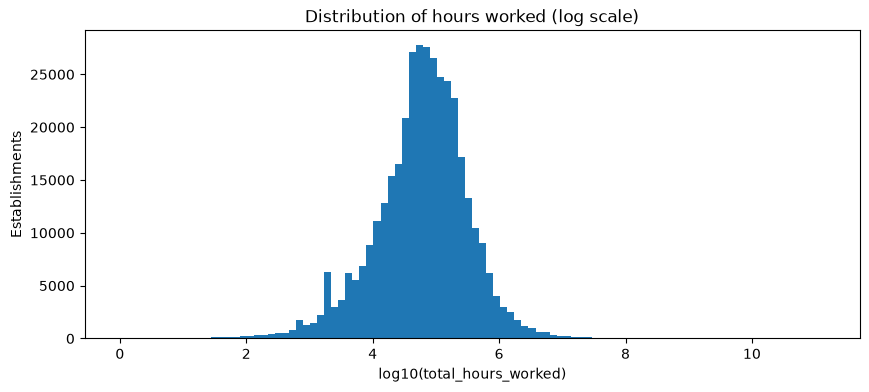

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(hours[hours > 0]), bins=100)
ax.set_xlabel('log10(total_hours_worked)')
ax.set_ylabel('Establishments')
ax.set_title('Distribution of hours worked (log scale)')
plt.show()

### Hours per employee

A full-time employee works about 2,000 hours a year, nobody can work more than 8,760 (24 × 365).

In [12]:
has_employees = df['annual_average_employees'] > 0
df['hours_per_employee'] = np.where(valid_hours & has_employees, df['total_hours_worked'] / df['annual_average_employees'], np.nan)

hpe = df['hours_per_employee']
print(hpe.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_string(), end='\n\n')
print(f'Employees <= 0:              {(~has_employees).sum():,}')
print(f'Hours/employee < 500:        {(hpe < 500).sum():,}')
print(f'Hours/employee > 4,000:      {(hpe > 4_000).sum():,}')
print(f'Hours/employee > 8,760:      {(hpe > 8_760).sum():,}  (physically impossible)')

count         378,649.00
mean           37,263.28
std         7,585,499.12
min                 0.00
1%                163.39
5%                667.37
25%             1,414.53
50%             1,794.13
75%             2,050.71
95%             2,482.90
99%             3,715.49
max     2,171,072,857.14

Employees <= 0:              4,466
Hours/employee < 500:        12,104
Hours/employee > 4,000:      3,352
Hours/employee > 8,760:      1,996  (physically impossible)


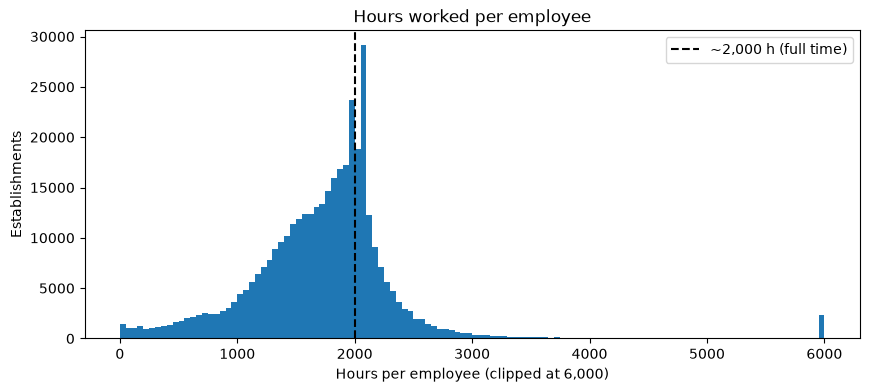

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hpe.clip(upper=6_000).dropna(), bins=120)
ax.axvline(2_000, color='black', linestyle='--', label='~2,000 h (full time)')
ax.set_xlabel('Hours per employee (clipped at 6,000)')
ax.set_ylabel('Establishments')
ax.set_title('Hours worked per employee')
ax.legend()
plt.show()

## 8. TRIR distribution

TRIR = 0:    168,879  (44.3%)
TRIR >  20:  12,997
TRIR >  50:  2,898
TRIR > 100:  1,356


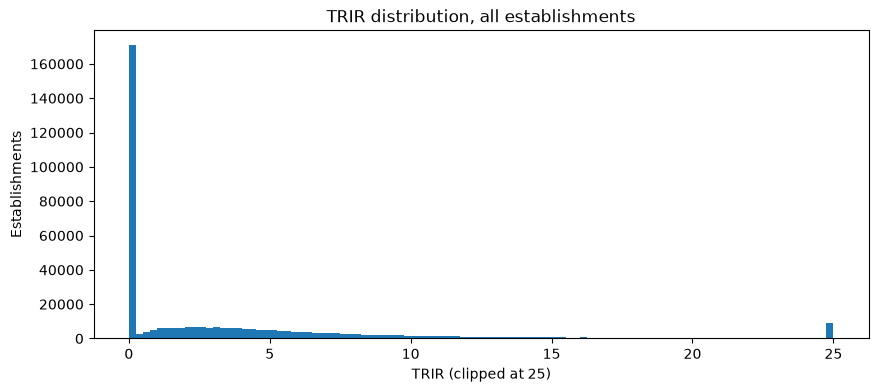

In [14]:
trir = df['trir'].dropna()
print(f'TRIR = 0:    {(trir == 0).sum():,}  ({(trir == 0).mean():.1%})')
for threshold in [20, 50, 100]:
    print(f'TRIR > {threshold:>3}:  {(trir > threshold).sum():,}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(trir.clip(upper=25), bins=100)
ax.set_xlabel('TRIR (clipped at 25)')
ax.set_ylabel('Establishments')
ax.set_title('TRIR distribution, all establishments')
plt.show()

In [ ]:
df.nlargest(15, 'trir')[['establishment_name', 'naics_code', 'annual_average_employees',
                         'total_hours_worked', 'recordable_cases', 'trir', 'hours_per_employee']]

,establishment_name,naics_code,annual_average_employees,total_hours_worked,recordable_cases,trir,hours_per_employee
263432,North County Transit District,485113,1,1,36,"7,200,000.00",1.00
153282,City of San Fernando,921190,1,1,35,"7,000,000.00",1.00
90089,City of Buena Park,921190,1,1,29,"5,800,000.00",1.00
128959,Rancho Santa Fe Fire Protection District,922160,1,1,10,"2,000,000.00",1.00
102962,San Miguel Consolidated Fire Protection District,922160,1,1,7,"1,400,000.00",1.00
85368,Sans Peur Delivery LLC,492210,57,5,17,"680,000.00",0.09
276022,UPMC Medical Education,621111,2096,56,177,"632,142.86",0.03
75256,Fire Station,922160,43,1,2,"400,000.00",0.02
93619,Berkeley Nutritional Manufacturing Corporation,325411,99,2,2,"200,000.00",0.02
283633,Allegria Nursing & Rehab,623110,179,2,2,"200,000.00",0.01


## 9. Logical consistency

In [16]:
checks = {
    'Says no injuries (code 2) but has cases': (df['no_injuries_illnesses'] == 2) & (df['recordable_cases'] > 0),
    'Says injuries (code 1) but has 0 cases': (df['no_injuries_illnesses'] == 1) & (df['recordable_cases'] == 0),
    'Recordable cases > average employees': df['recordable_cases'] > df['annual_average_employees'],
    'DAFW days > 0 but DAFW cases = 0': (df['total_dafw_days'] > 0) & (df['total_dafw_cases'] == 0),
    'DAFW cases > 0 but DAFW days = 0': (df['total_dafw_cases'] > 0) & (df['total_dafw_days'] == 0),
    'Negative value in any case column': (df[['total_deaths', 'total_dafw_cases', 'total_djtr_cases', 'total_other_cases']] < 0).any(axis=1),
}
pd.DataFrame({
    'rows': {name: mask.sum() for name, mask in checks.items()},
    'pct': {name: mask.mean() * 100 for name, mask in checks.items()},
})

,rows,pct
Says no injuries (code 2) but has cases,0,0.00
Says injuries (code 1) but has 0 cases,8,0.00
Recordable cases > average employees,412,0.11
DAFW days > 0 but DAFW cases = 0,229,0.06
DAFW cases > 0 but DAFW days = 0,258,0.07
Negative value in any case column,0,0.00


## 10. NAICS codes

Invalid submissions show up as missing

In [17]:
naics = df['naics_code']
print(f'Missing NAICS:        {naics.isna().sum():,}')
print('Code length distribution:')
print(naics.str.len().value_counts(dropna=False).sort_index().to_string())

df['naics_6'] = naics.where(naics.str.fullmatch(r'\d{6}'))
df['naics_4'] = df['naics_6'].str[:4]
df['naics_2'] = df['naics_6'].str[:2]
print(f'\nValid 6-digit codes: {df["naics_6"].notna().sum():,} rows, {df["naics_6"].nunique():,} distinct codes')

Missing NAICS:        0
Code length distribution:
naics_code
6    383277



Valid 6-digit codes: 383,277 rows, 1,178 distinct codes


In [18]:
bad_naics_year = ~df['naics_year'].isin([2012, 2017, 2022])
print(f'Rows with naics_year not in (2012, 2017, 2022): {bad_naics_year.sum():,}')
df.loc[bad_naics_year, ['establishment_name', 'naics_code', 'naics_year', 'industry_description']].head(10)

Rows with naics_year not in (2012, 2017, 2022): 170


,establishment_name,naics_code,naics_year,industry_description
19813,493006-East Providence | RI | OST-100,485410,0.00,485410
19824,293001-Hopkinton (Region Admin) | MA | SMA-000,485410,0.00,485410
30334,143022-Pasadena | CA | 143022,485410,0.00,485410
30359,403014-Londonderry | NH | LON-000,485410,0.00,485410
30360,403013-Windham / Pelham | NH | GOF-400,485410,0.00,485410
30361,403010-Rochester | NH | 403010,485410,0.00,485410
30362,313010-Kezar Falls | ME | SME-500,485410,0.00,485410
30363,313006-York | ME | SME-100,485410,0.00,485410
30364,403012-Merrimack | NH | GOF-300,485410,0.00,485410
30376,443022-Fonda | NY | 443022,485410,0.00,485410


In [ ]:
# 2 digit sector
df['naics_2'].value_counts().head(25)

naics_2
62    46653
44    41241
23    37281
56    32602
42    30686
33    29837
49    24881
32    20714
72    19387
45    18509
48    15648
53    12321
31     8611
92     8154
81     7129
22     7069
11     4945
54     4913
71     3885
61     3012
51     2533
55     1559
52      856
21      836
99        5
Name: count, dtype: Int64

## 11. Cohort sizes


**Note:** These counts are before cleaning. After dropping invalid rows, cohorts will be smaller.

In [ ]:
MIN_COHORT = 30

cohort_6 = df['naics_6'].value_counts()
cohort_4 = df['naics_4'].value_counts()

def cohort_summary(counts, label):
    ok = counts >= MIN_COHORT
    return {
        'level': label,
        'cohorts': len(counts),
        f'cohorts >= {MIN_COHORT}': int(ok.sum()),
        'pct cohorts ok': ok.mean() * 100,
        'pct establishments covered': counts[ok].sum() / counts.sum() * 100,
        'median cohort size': counts.median(),
    }

pd.DataFrame([cohort_summary(cohort_6, '6-digit'), cohort_summary(cohort_4, '4-digit')]).set_index('level')

,cohorts,cohorts >= 30,pct cohorts ok,pct establishments covered,median cohort size
level,,,,,
6-digit,1178,791,67.15,99.09,77.50
4-digit,358,291,81.28,99.83,321.50


In [ ]:
level = np.select(
    [df['naics_6'].map(cohort_6).ge(MIN_COHORT).fillna(False), df['naics_4'].map(cohort_4).ge(MIN_COHORT).fillna(False)],
    ['6-digit', '4-digit'],
    default='no percentile',
)
pd.Series(level, index=df.index).where(df['naics_6'].notna(), 'invalid NAICS').value_counts()

6-digit          379772
4-digit            2861
no percentile       644
Name: count, dtype: int64

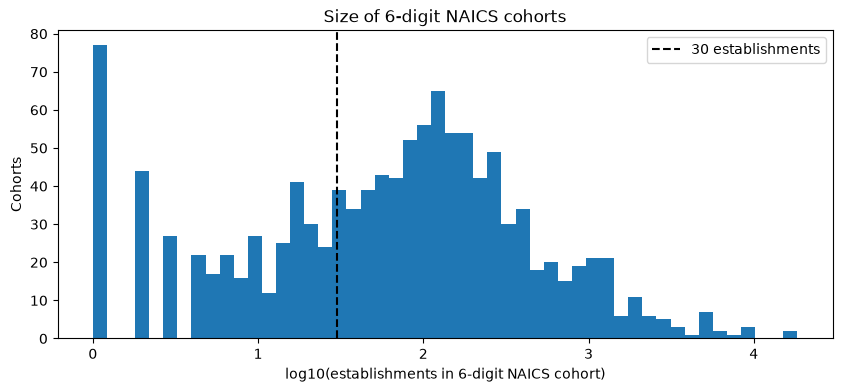

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(cohort_6), bins=50)
ax.axvline(np.log10(MIN_COHORT), color='black', linestyle='--', label=f'{MIN_COHORT} establishments')
ax.set_xlabel('log10(establishments in 6-digit NAICS cohort)')
ax.set_ylabel('Cohorts')
ax.set_title('Size of 6-digit NAICS cohorts')
ax.legend()
plt.show()

## 12. Candidate cleaning rules


In [23]:
MIN_HOURS = 10_000         # candidate — revisit with section 7
MAX_HOURS_PER_EMP = 8_760  # physical limit

rules = {
    'hours <= 0 or null': ~valid_hours,
    f'hours < {MIN_HOURS:,}': valid_hours & (df['total_hours_worked'] < MIN_HOURS),
    'employees <= 0': ~has_employees,
    f'hours/employee > {MAX_HOURS_PER_EMP:,}': df['hours_per_employee'] > MAX_HOURS_PER_EMP,
    'invalid or missing NAICS': df['naics_6'].isna(),
    'naics_year not 2012/2017/2022': bad_naics_year,
    'cases > employees': df['recordable_cases'] > df['annual_average_employees'],
}

drop_any = pd.concat(rules, axis=1).fillna(False).any(axis=1)
impact = pd.DataFrame({
    'rows dropped': {name: mask.sum() for name, mask in rules.items()},
    'pct': {name: mask.mean() * 100 for name, mask in rules.items()},
})
impact.loc['ANY RULE (combined)'] = [drop_any.sum(), drop_any.mean() * 100]
print(f'Rows kept: {(~drop_any).sum():,} of {len(df):,}')
impact

Rows kept: 328,825 of 383,277


,rows dropped,pct
hours <= 0 or null,"1,834.00",0.48
"hours < 10,000","50,253.00",13.11
employees <= 0,"4,466.00",1.17
"hours/employee > 8,760","1,996.00",0.52
invalid or missing NAICS,0.00,0.00
naics_year not 2012/2017/2022,170.00,0.04
cases > employees,412.00,0.11
ANY RULE (combined),"54,452.00",14.21
